## PyTorch Workflow

In [1]:
import torch

In [2]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
X[:10], X.shape

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 torch.Size([50, 1]))

In [3]:
y = weight * X + bias
y[:10], y.shape

(tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 torch.Size([50, 1]))

## Splitting data into training and testing sets

In [4]:
train_split = int(0.8 * len(X))
train_split

40

In [5]:
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_test), len(X_train), len(y_test), len(y_train)

(10, 40, 10, 40)

## Visualizing our data

In [6]:
import matplotlib.pyplot as plt

In [7]:
def plot_predictions(train_data=X_train,train_labels=y_train,test_data=X_test,test_labels=y_test,predictions=None):
  plt.figure(figsize=(10, 7))

  # Traing data in blue
  plt.scatter(train_data, train_labels, c="b", s=8, label="Training data")

  # Testing data in green
  plt.scatter(test_data, test_labels, c="g", s=8, label="Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=8, label="Predictions")

  plt.legend(prop={ "size": 14 })





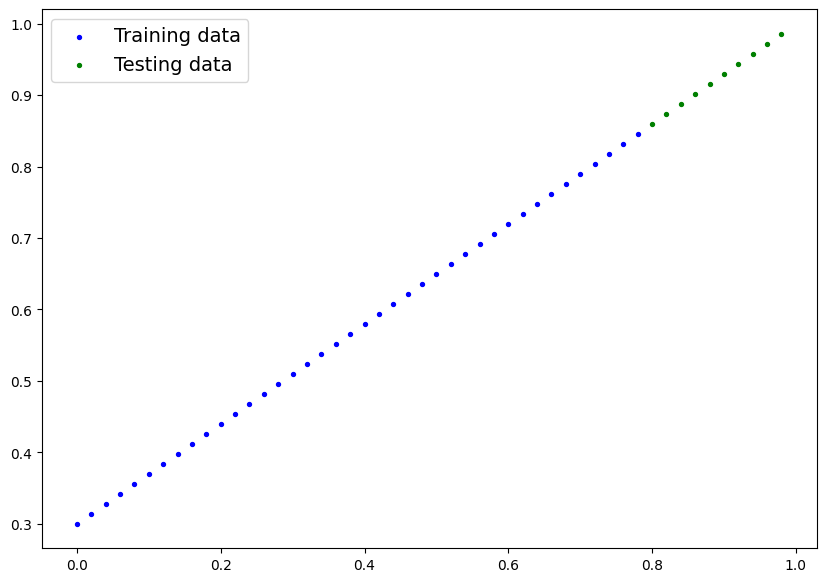

In [8]:
plot_predictions()

## Creating my first PyTorch Model

In [9]:
from torch import nn

In [10]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    # Start with random weights and bias and try to adjust it to the ideal values
    self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

  # forward method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

## Checking our PyTorch model

In [11]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [12]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

## Making predictions with our model

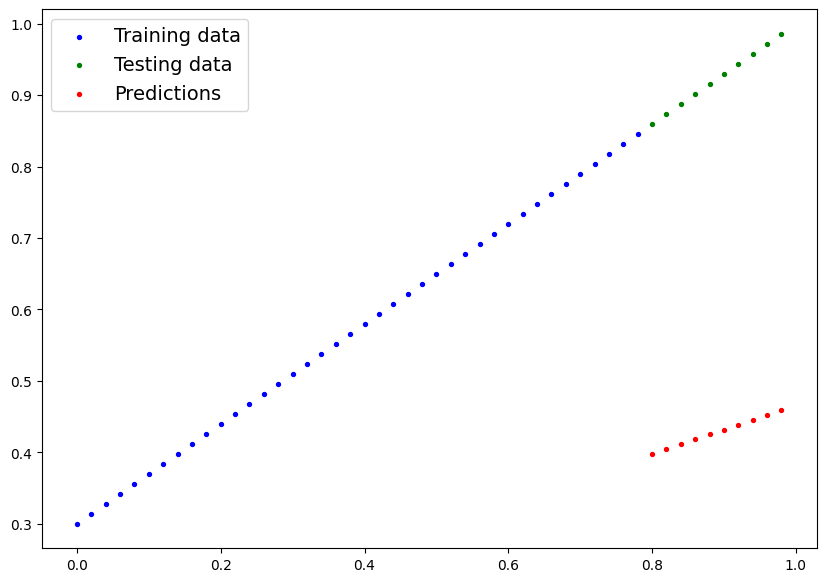

In [13]:
with torch.inference_mode():
  y_preds = model_0(X_test)

plot_predictions(predictions=y_preds)

## Setting up a loss function and optimizer

In [14]:
loss_fn = nn.L1Loss()

In [15]:
# Stochastic Gradient Descent
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.0005) # Learning rate

## Building a training and a testing loop

In [ ]:
epochs = 10000

epochs_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
  model_0.train() # Training mode

  # 1. Forward pass (make predictions)
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)

  # 3. Gradient zero grad (Zero the gradients)
  optimizer.zero_grad()

  # 4. Loss backward ( Backpropagation )
  loss.backward()

  # 5. Gradient step ( Perform Gradient Descent )
  optimizer.step()

  # Testing
  model_0.eval()
  with torch.inference_mode():
    test_pred = model_0(X_test)
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 1000 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
    print(model_0.state_dict())
    epochs_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)

Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.4938625693321228
OrderedDict({'weights': tensor([0.3369]), 'bias': tensor([0.1293])})
Epoch: 1000 | Loss: 0.041596803814172745 | Test loss: 0.1009359359741211
OrderedDict({'weights': tensor([0.4923]), 'bias': tensor([0.3839])})
Epoch: 2000 | Loss: 0.024351513013243675 | Test loss: 0.05689507722854614
OrderedDict({'weights': tensor([0.5789]), 'bias': tensor([0.3509])})
Epoch: 3000 | Loss: 0.007178329862654209 | Test loss: 0.016734648495912552
OrderedDict({'weights': tensor([0.6644]), 'bias': tensor([0.3150])})
Epoch: 4000 | Loss: 0.00034949928522109985 | Test loss: 0.0001248538465006277
OrderedDict({'weights': tensor([0.6998]), 'bias': tensor([0.3003])})
Epoch: 5000 | Loss: 0.00034949928522109985 | Test loss: 0.0001248538465006277
OrderedDict({'weights': tensor([0.6998]), 'bias': tensor([0.3003])})
Epoch: 6000 | Loss: 0.00034949928522109985 | Test loss: 0.0001248538465006277
OrderedDict({'weights': tensor([0.6998]), 'bias': tensor([0.3

In [ ]:
with torch.inference_mode():
  y_preds_test = model_0(X_test)

plot_predictions(predictions=y_preds_test)

In [ ]:
# Plot the loss curves

loss_ndarray = torch.tensor(loss_values).detach().numpy()
test_loss_ndarray = torch.tensor(test_loss_values).detach().numpy()

plt.plot(epochs_count, loss_ndarray, label="Training loss")
plt.plot(epochs_count, test_loss_ndarray, label="Testing loss")
plt.title("Training and Testing loss throughout the epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

## Saving a model

In [ ]:
from pathlib import Path

MODELS_DIR_PATH = Path("models")
MODELS_DIR_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR_PATH / "01_pytorch_workflow_model_0.pth"

torch.save(obj=model_0.state_dict(), f=MODEL_PATH)

## Loading a model

In [ ]:
loaded_model_0 = LinearRegressionModel()

loaded_model_0.load_state_dict(torch.load(f=MODEL_PATH))

with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

y_preds_test == loaded_model_preds